In [ ]:
from pathlib import Path

import numpy as np
import numpy.typing as npt
import torch
import torch.nn.functional as F
from accelerate import Accelerator
from safetensors import safe_open
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm, trange

from lib.dataset import MatlabDataset, frame_accel_3d, frame_damage, subsample
from lib.densenet import SDIDenseNet
from lib.midn import Midn

In [ ]:
def add_noise(signal: npt.NDArray[np.float_], snr: float) -> npt.NDArray[np.float_]:
    linear_snr = 10.0 ** (snr / 10.0)
    noise_var = signal.var(1)[:, None, :] / linear_snr
    noise_var[np.abs(noise_var) < 1e-12] = linear_snr  # For null signals, use linear_snr directly
    e = np.random.randn(*signal.shape) * (noise_var * 2.0)**0.5 / 2
    return signal + e

In [ ]:
class SafetensorsDataset(Dataset):
    def __init__(self, root: Path | str, getters) -> None:
        super().__init__()
        self.root = Path(root)
        self.files = list(self.root.glob("*.safetensors"))
        self.getters = getters

    def __len__(self) -> int: return len(self.files)

    def __getitem__(self, index: int):
        file = self.files[index]
        data = safe_open(file, framework="numpy")
        return [getter(data) for getter in self.getters]

In [ ]:
# sparse_indices = [3, 6, 8, 10, 16, 47, 50, 53, 56]


def input_preprocess(data, n_sensors=65, sensor_dim=1, snr=-1.0) -> npt.NDArray[np.float32]:
    accel = data.get_tensor("acc").reshape(1000, 65, 3).transpose(2, 0, 1)
    accel = accel[:sensor_dim, :500]
    # accel = accel[..., sparse_indices]
    if snr > 0.0:
        accel = add_noise(accel, snr)
    return accel.astype(np.float32)  # type: ignore


def val_input_preprocess(data, sensor_dim=1, snr=-1.0):
    accel = data.get_tensor("acc").reshape(1000, 65, 3).transpose(2, 0, 1)
    accel = accel[:sensor_dim, :500]
    # accel = accel[..., sparse_indices]
    if snr > 0.0:
        accel = add_noise(accel, snr)
    return accel.astype(np.float32)


def target_preprocess(data) -> npt.NDArray[np.float32]:
    return data.get_tensor("target").astype(np.float32) / 0.15 - 1


def get_dataloaders(name, snr=0.0):
    train_ds = SafetensorsDataset(f"data/safetensors/unc=0/{name}/", [lambda x: input_preprocess(x, snr=snr), target_preprocess])
    val_ds = SafetensorsDataset(f"data/safetensors/unc=0/{name}/", [lambda x: val_input_preprocess(x, snr=snr), target_preprocess])

    train, valtest = train_test_split(np.arange(len(train_ds)), test_size=0.3, random_state=42)
    val, test = train_test_split(valtest, test_size=0.5, random_state=42)

    train_dl = DataLoader(Subset(train_ds, train), batch_size=128, shuffle=True, num_workers=12)
    val_dl = DataLoader(Subset(val_ds, val), batch_size=32, shuffle=False, num_workers=12)
    test_dl = DataLoader(Subset(val_ds, test), batch_size=32, shuffle=False, num_workers=12)
    return train_dl, val_dl, test_dl
# len(train_dl), len(val_dl)

In [ ]:
from lib.midn import importance_dropout


class Midn(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        importance_dropout: float = 0.0,
        temperature: float = 1.0,
        val_temperature: float | None = None,
        pred_activation: "Callable[[], nn.Module]" = nn.Tanh,
    ) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.layer = nn.Conv1d(in_channels, 2 * out_channels, 1)
        self.pred_activation = pred_activation()
        self.temperature = temperature
        self.val_temperature = val_temperature or temperature
        self.importance_dropout = importance_dropout

    def forward(
        self, x: torch.Tensor, reduce: bool = True
    ) -> "Tensor | tuple[Tensor, Tensor]":
        x = self.layer(x)
        prediction = x[:, : self.out_channels, :]
        importance = (
            x[:, self.out_channels :, :] * (self.temperature if self.training else self.val_temperature)
        )
        if self.training:
            importance = importance_dropout(importance, self.importance_dropout)

        importance = importance.softmax(-1)
        dmg_importance, loc_importance = importance[:, :1], importance[:, 1:]
        dmg_prediction, loc_prediction = self.pred_activation(prediction[:, :1]), prediction[:, 1:]

        if reduce:
            return (dmg_prediction * dmg_importance).sum(2), (loc_prediction * loc_importance).sum(2)
        else:
            return dmg_prediction, dmg_importance, loc_prediction, loc_importance

In [ ]:
def get_model():
    dropout = 0.0
    head_dropout = 0.5   # 0.166946
    feature_extractor = SDIDenseNet(1, structure=(6, 6, 6), bn_params={})
    neck = nn.Sequential(
        nn.Flatten(1, 2),
        nn.Conv1d(6000, 768, 1),
        nn.ReLU(True),
        nn.Dropout(dropout),
        nn.Conv1d(768, 768, 1),
        nn.ReLU(True),
    )
    head = Midn(768, 71, head_dropout, temperature=1e-2, val_temperature=1e-2)
    model = nn.Sequential(feature_extractor, neck, head)
    return model

In [ ]:
from random import random


@torch.no_grad()
def randomise_bag_size(x: torch.Tensor, drop_rate: float = 10/65) -> tuple[torch.Tensor, torch.Tensor]:
    while not (mask := torch.rand(x.size(-1)) < drop_rate).any():
        pass
    return x[..., mask]

In [ ]:
def train_one_epoch(model, opt, sched, train_dl, accel, ema = None) -> float:
    model.train()
    accum = 0.
    for x, y in train_dl:
        y_dmg, y_loc = y.max(-1, keepdim=True)
        y_loc = y_loc[:, 0]
        opt.zero_grad()
        with accel.autocast():
            # x = x[..., 1:-1]  # remove the stationary sensors
            x = randomise_bag_size(x)
            # x = add_noise(x)
            y_hat_dmg, y_hat_loc = model(x)
            dmg_loss = F.mse_loss(y_hat_dmg, y_dmg)
            loc_loss = F.cross_entropy(y_hat_loc, y_loc)
            loss = dmg_loss + loc_loss
            if ema is not None:
                ema.update_parameters(model)
        accel.backward(loss)
        opt.step()
        sched.step()
        accum += loss.item()
    accum /= len(train_dl)
    return accum

In [ ]:
from functools import lru_cache

@lru_cache
def gen_combos(
    num_combos: int,
    length: int,
    num_sensors: int,
) -> torch.Tensor:
    rng = torch.Generator().manual_seed(42)
    out = torch.empty((num_combos, num_sensors), dtype=torch.long)
    for i in range(num_combos):
        torch.randperm(num_sensors, out=out[i], generator=rng)
        while (out[i:i+1, :length] == out[:i, :length]).all(1).any():
            # ensure no duplicates
            torch.randperm(num_sensors, out=out[i], generator=rng)
    return out[:, :length].T


@torch.inference_mode()
def val_one_epoch(model, val_dl, clen=10) -> float:
    model.eval()
    state = deepcopy(model.state_dict())
    # combos = torch.combinations(torch.arange(65), r=clen)
    combos = gen_combos(51, clen, num_sensors=9)
    total_losses = torch.zeros((combos.size(0),))
    total_mse = torch.zeros((combos.size(0),))
    loc_corr = torch.zeros((combos.size(0),))
    for x, y in val_dl:
        # x = x[..., 1:-1]  # remove the stationary sensors
        y_dmg, y_loc = y.max(-1, keepdim=True)
        y_loc = y_loc[:, 0]

        y_hat_dmg, i_dmg, y_hat_loc, i_loc = model[2](model[:2](x.float()), False)
        y_hat_dmg, y_hat_loc = y_hat_dmg[..., combos], y_hat_loc[..., combos]
        i_dmg, i_loc = i_dmg[..., combos], i_loc[..., combos]
        i_dmg = i_dmg / (i_dmg.sum(-1, keepdim=True) + 1e-12)
        i_loc = i_loc / (i_loc.sum(-1, keepdim=True) + 1e-12)
        dmg_preds = torch.einsum("becs,becs->bec", y_hat_dmg, i_dmg)
        loc_preds = torch.einsum("becs,becs->bec", y_hat_loc, i_loc)
        l_dmg = F.mse_loss(dmg_preds, y_dmg[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()
        l_loc = F.cross_entropy(loc_preds, y_loc[..., None].expand(-1, loc_preds.size(-1)), reduction="none").sum(0).cpu()
        l = l_dmg + l_loc
        total_losses += l

        distributed_pred = (dmg_preds.add(1).div(2) * loc_preds.softmax(1)).mul(2).sub(1)
        total_mse += F.mse_loss(distributed_pred, y[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()

        loc_corr += (loc_preds.argmax(1) == y_loc[:, None]).sum(0).cpu()

    model.load_state_dict(state)
    return torch.median(total_losses).item() / len(val_dl.dataset), torch.median(total_mse).item() / len(val_dl.dataset), torch.median(loc_corr).item() / len(val_dl.dataset)

In [ ]:
from scipy.io import loadmat


mat = loadmat("./data/Testing_SingleEAcc9Sensor0.5sec.mat")
test_data = torch.from_numpy(mat["Testing_Data"]).float()
test_target = torch.from_numpy(mat["Testing_label"]).float()
def do_real_test(model):
    with torch.inference_mode():
        model.eval()
        dmg_pred, loc_pred = model(test_data[None, None, ...].cuda())
    dmg_pred = dmg_pred.squeeze().add(1).mul_(0.15).item()
    loc_nll = -(loc_pred.squeeze().log_softmax(-1)[11].item())
    max_nll = -(loc_pred.squeeze().log_softmax(-1).max().item())
    smooth = dmg_pred * loc_pred.squeeze().softmax(-1)
    hard = torch.zeros_like(test_target.squeeze())
    hard[loc_pred.argmax()] = dmg_pred
    return {
        "rw_mse": (dmg_pred - 0.125) ** 2,
        "rw_nll": loc_nll,
        "rw_err_s": ((smooth.cpu() - test_target.squeeze()) ** 2).mean().item(),
        "rw_err_h": ((hard - test_target.squeeze()) ** 2).mean().item()
    }
    # print(f"{dmg_pred:7.04f} @ {loc_pred.squeeze().argmax().item():d} | MSE: {(dmg_pred - 0.125) ** 2:10.04e}, NLL: {loc_nll:10.04e} (best: {max_nll:10.04e})")

In [ ]:
def get_opt_and_sched(model, train_dl, epochs):
    # base_lr = 8.65e-4  # 0.0008649464567
    base_lr = 5e-4
    opt = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=1.0e-2, betas=(0.9, 0.999))  # 0.013389125
    # opt = torch.optim.SGD(model.parameters(), lr=base_lr*30, momentum=0.9, nesterov=True, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, base_lr, epochs=epochs, steps_per_epoch=len(train_dl))
    return opt, sched

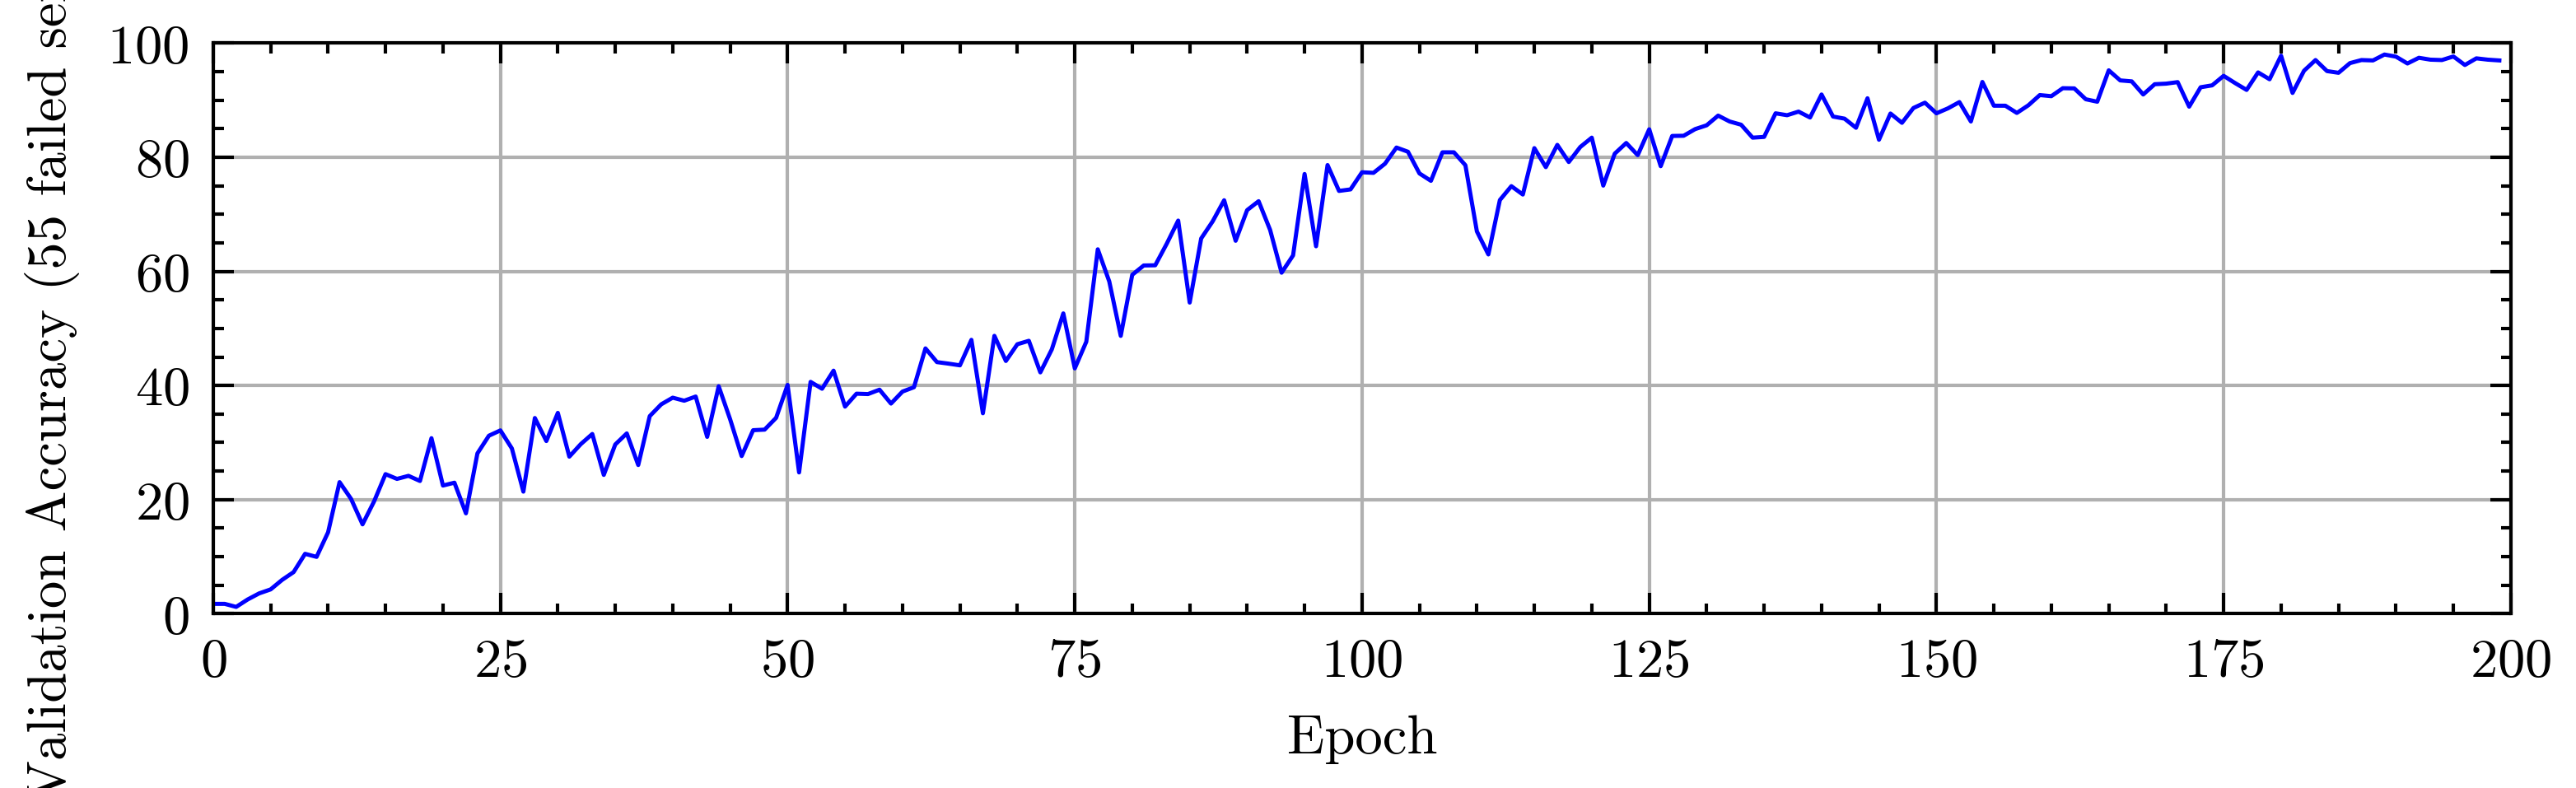

In [ ]:
plt.figure(figsize=(6, 1.5))
plt.plot(other_stats[0], color='blue', linewidth=0.6)
plt.ylim(0, 100)
plt.ylabel("Validation Accuracy (55 failed sensors)")
plt.xlim(0, 200)
plt.xlabel("Epoch")
plt.grid()

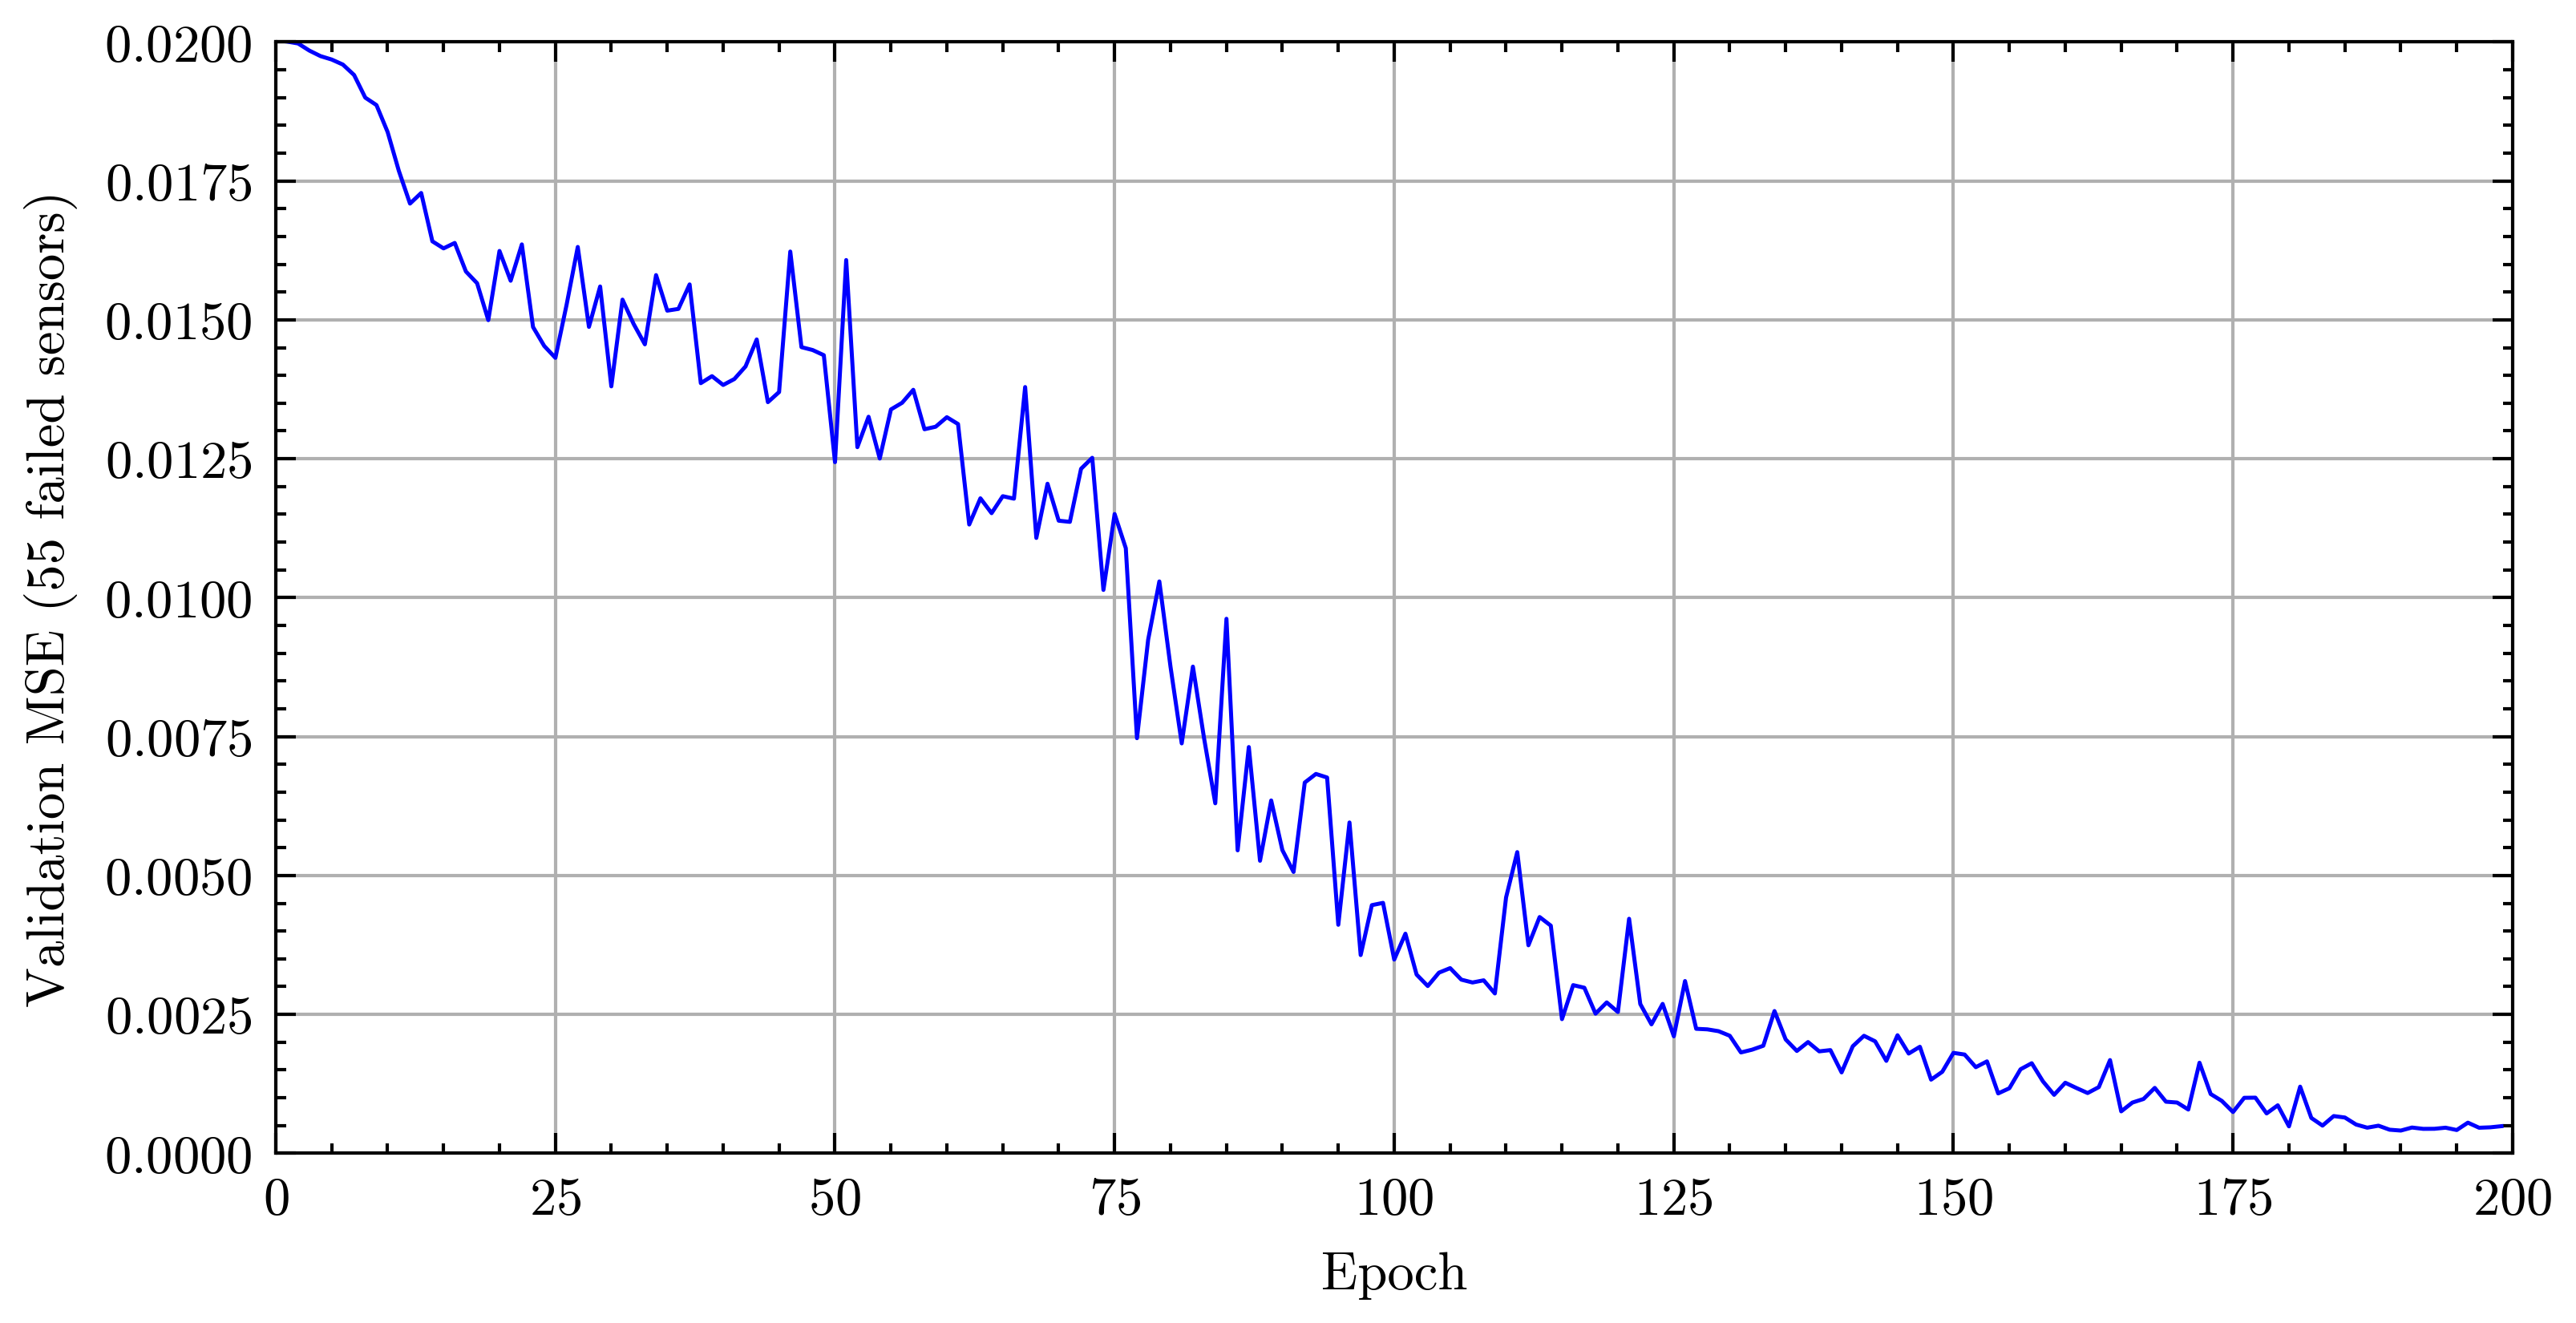

In [ ]:
plt.figure(figsize=(6, 3))
plt.plot(other_stats[1], color='blue', linewidth=0.6)
plt.ylim(0.000, 0.02)
# plt.yscale("log")
plt.ylabel("Validation MSE (55 failed sensors)")
plt.xlim(0, 200)
plt.xlabel("Epoch")
plt.grid()

In [ ]:
with torch.inference_mode():
    model.eval()
    # all_combos = [torch.combinations(torch.arange(9), i) for i in trange(1, 10)]
    # total_losses = [torch.zeros(len(combos)) for combos in all_combos]
    # total_mse = [torch.zeros(len(combos)) for combos in all_combos]
    # total_acc = [torch.zeros(len(combos)) for combos in all_combos]

    all_combos = torch.stack([
        torch.randperm(65)
        for _ in trange(664)
    ], 0)
    total_losses = torch.zeros_like(all_combos, dtype=float).T
    total_mse = torch.zeros_like(all_combos, dtype=float).T
    total_acc = torch.zeros_like(all_combos, dtype=float).T

    for x, y in tqdm(val_dl):
        # x = x[..., 1:-1]  # remove the stationary sensors
        y_dmg, y_loc = y.max(-1, keepdim=True)
        y_loc = y_loc[:, 0]

        # for n, combos in enumerate(all_combos):
        #     n += 1
        for n in range(1, 66):
            combos = all_combos[:, :n]
            y_hat_dmg, i_dmg, y_hat_loc, i_loc = model[2](model[:2](x.float()), False)
            y_hat_dmg, y_hat_loc = y_hat_dmg[..., combos], y_hat_loc[..., combos]
            i_dmg, i_loc = i_dmg[..., combos], i_loc[..., combos]
            i_dmg = i_dmg / (i_dmg.sum(-1, keepdim=True) + 1e-12)
            i_loc = i_loc / (i_loc.sum(-1, keepdim=True) + 1e-12)
            dmg_preds = torch.einsum("becs,becs->bec", y_hat_dmg, i_dmg)
            loc_preds = torch.einsum("becs,becs->bec", y_hat_loc, i_loc)
            l_dmg = F.mse_loss(dmg_preds, y_dmg[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()
            l_loc = F.cross_entropy(loc_preds, y_loc[..., None].expand(-1, loc_preds.size(-1)), reduction="none").sum(0).cpu()
            l = l_dmg + l_loc

            total_losses[n-1] += l

            distributed_pred = (dmg_preds.add(1).div(2) * loc_preds.softmax(1)).mul(2).sub(1)
            total_mse[n-1]  += F.mse_loss(dmg_preds.add(1).mul(0.15), y_dmg[..., None].expand(-1, -1, dmg_preds.size(-1)).add(1).mul(0.15), reduction="none").mean(1).sum(0).cpu()
            # total_mse[n-1] += F.mse_loss(distributed_pred, y[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()

            total_acc[n-1] += (loc_preds.argmax(1) == y_loc[:, None]).sum(0).cpu()

  0%|          | 0/664 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

In [ ]:
with torch.inference_mode():
    model.eval()
    all_combos = torch.arange(9)[None, :]
    # for x, y in tqdm(val_dl):
        # x = x[..., 1:-1]  # remove the stationary sensors
    x, y = next(iter(test_dl))
    y_dmg, y_loc = y.max(-1, keepdim=True)
    y_loc = y_loc[:, 0]
    combos = all_combos[:, :]
    y_hat_dmg, i_dmg, y_hat_loc, i_loc = model[2](model[:2](x.float()), False)
    y_hat_dmg, y_hat_loc = y_hat_dmg[..., combos], y_hat_loc[..., combos]
    i_dmg, i_loc = i_dmg[..., combos], i_loc[..., combos]
    i_dmg = i_dmg / (i_dmg.sum(-1, keepdim=True) + 1e-12)
    i_loc = i_loc / (i_loc.sum(-1, keepdim=True) + 1e-12)
    dmg_preds = torch.einsum("becs,becs->bec", y_hat_dmg, i_dmg)
    loc_preds = torch.einsum("becs,becs->bec", y_hat_loc, i_loc)
    l_dmg = F.mse_loss(dmg_preds, y_dmg[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()
    l_loc = F.cross_entropy(loc_preds, y_loc[..., None].expand(-1, loc_preds.size(-1)), reduction="none").sum(0).cpu()
    l = l_dmg + l_loc

    distributed_pred = (dmg_preds.add(1).div(2) * loc_preds.softmax(1)).mul(2).sub(1)

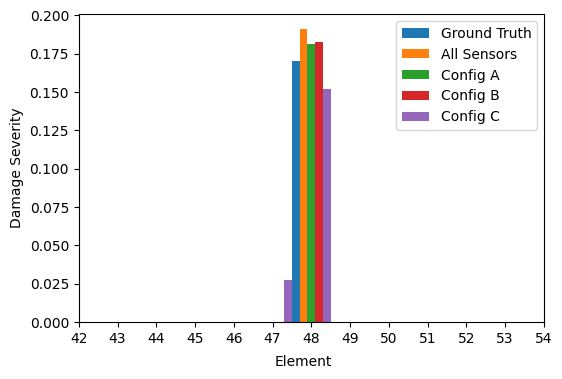

In [ ]:
IDX = 12
# with plt.xkcd():
fig = plt.figure(figsize=(6, 4))
plt.bar(torch.arange(70) + 0.6, (y[IDX].detach().cpu() + 1) * 0.15, width=0.2, label="Ground Truth")
plt.bar(torch.arange(70) + 0.8, (dps[-1][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="All Sensors")
plt.bar(torch.arange(70) + 1.0, (dps[5][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config A")
plt.bar(torch.arange(70) + 1.2, (dps[2][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config B")
plt.bar(torch.arange(70) + 1.4, (dps[0][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config C")
plt.xticks(torch.arange(13+42))
plt.xlim(42, 54)
# plt.ylim(0, 0.02)

plt.gca().legend(loc="upper right")
plt.gcf().text(0.5, 0.0, "Element", ha="center")
plt.gca().set_ylabel("Damage Severity")
fig.suptitle("")

fig

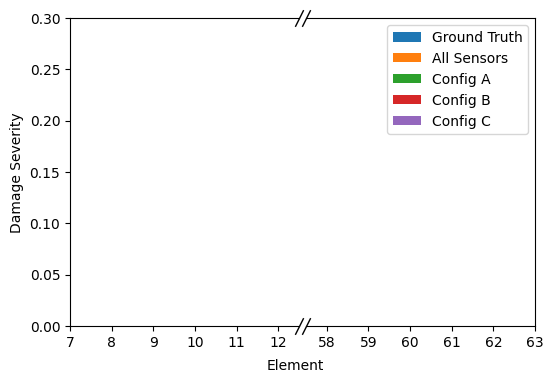

In [ ]:
# IDX=1
# IDX=2
IDX = 12
# with plt.xkcd():
fig, axs = plt.subplots(ncols=2, sharey=True, figsize=(6, 4))
for ax in axs:
    ax.bar(torch.arange(70) + 0.6, (y[IDX].detach().cpu() + 1) * 0.15, width=0.2, label="Ground Truth")
    ax.bar(torch.arange(70) + 0.8, (dps[-1][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="All Sensors")
    ax.bar(torch.arange(70) + 1.0, (dps[5][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config A")
    ax.bar(torch.arange(70) + 1.2, (dps[2][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config B")
    ax.bar(torch.arange(70) + 1.4, (dps[0][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config C")
    ax.set_xticks(torch.arange(70)+1)
    ax.set_ylim(0, 0.3)
    # plt.xlim(65, 70)
fig.subplots_adjust(wspace=0.03)
axs[0].set_xlim(7, 12.5)
axs[1].set_xlim(57.5, 63)

axs[0].spines.right.set_visible(False)
axs[1].spines.left.set_visible(False)
axs[1].tick_params(axis="y", left=False, right=False)

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
axs[0].plot([1, 1], [0, 1], transform=axs[0].transAxes, **kwargs)
axs[1].plot([0, 0], [0, 1], transform=axs[1].transAxes, **kwargs)

axs[1].legend(loc="upper right")
fig.text(0.5, 0.0, "Element", ha="center")
axs[0].set_ylabel("Damage Severity")
fig.suptitle("")
fig

In [ ]:
# Inspect contents of SingleElementDamage.mat
from pathlib import Path
import numpy as np
from scipy.io import loadmat

mat_path = Path(r"data/SingleElementDamage.mat")
mat = loadmat(mat_path)

print(f"Loaded: {mat_path}")
print(f"Top-level keys ({len(mat.keys())}):")
for k in mat.keys():
    print("  ", k)

print("\n--- Data variables (excluding MATLAB metadata) ---")
data_keys = [k for k in mat.keys() if not k.startswith("__")]
for k in data_keys:
    v = mat[k]
    shape = getattr(v, "shape", None)
    dtype = getattr(v, "dtype", None)
    print(f"{k:30s} type={type(v).__name__:>12s}  shape={shape}  dtype={dtype}")

print("\n--- Quick preview (first few variables) ---")
for k in data_keys[:5]:
    v = mat[k]
    print(f"\n[{k}]")
    if isinstance(v, np.ndarray):
        print("shape:", v.shape, "dtype:", v.dtype)
        if v.size == 0:
            print("empty array")
        elif v.dtype == object:
            print("object array; first element type:", type(v.flat[0]).__name__)
        elif np.issubdtype(v.dtype, np.number):
            print("min/max/mean:", float(np.nanmin(v)), float(np.nanmax(v)), float(np.nanmean(v)))
            print("sample:", v.reshape(-1)[:10])
        else:
            print("sample:", v.reshape(-1)[:10])
    else:
        print("value:", v)

# Optional: if one variable is clearly your acceleration/label, inspect deeper:
# x = mat["Testing_Data"]   # replace with actual key
# y = mat["Testing_label"]  # replace with actual key
# print("Testing_Data:", x.shape, x.dtype)
# print("Testing_label:", y.shape, y.dtype)